# Stage A независимо: SimCSE поверх Stage-C чекпойнтов

Цель — проверить, **даёт ли SimCSE на summaries прирост поверх уже обученных Stage-C моделей**.

## Что делаем

1. **Загружаем Stage-C чекпойнты** из `./checkpoints_stageC/`:
   * `USER-bge-m3__mse.pt`
   * `mE5-instruct__cosent.pt`
   * `Qwen3-Emb-0.6B__mse.pt`
2. **Запоминаем стартовые метрики** каждой модели (`val_stsb`, `test_stsb`, `test_sts22`).
3. **Продолжаем обучение того же LoRA-адаптера** методом SimCSE (один и тот же текст с разными dropout-масками) на ~30k уникальных summaries из `RussianNLP/Mixed-Summarization-Dataset`. **Не создаём новый адаптер** — загруженные веса Stage-C служат стартовой точкой.
4. **Осторожные параметры обучения** — критично, чтобы не разрушить Stage-C:
   * Низкий LR (`1e-5` для XLM-R, `5e-5` для Qwen).
   * `max_epochs=2`, `patience=1` (быстрая остановка при ухудшении).
   * **Safety-stop**: если после первой эпохи `val_stsb` упал ниже **стартового Stage-C значения** — стоп немедленно, чекпойнт не пишем.
5. **Финальное сравнение** до/после. Если `val_stsb` вырос — сохраняем новый чекпойнт `./checkpoints_stageA/{model}__stageC_then_simcse.pt`. Если нет — оставляем Stage-C как есть (вывод: чисто SimCSE-добавка не помогает поверх доменного фитуна на STS, и логичнее сразу пробовать Stage B с парафразами).


In [ ]:
#!pip install -q -U "transformers>=4.45" "datasets>=2.18" "peft>=0.11" "accelerate" "scipy" "tqdm" "matplotlib"

In [ ]:
#!pip -q install -U "torch>=2.1" "transformers==4.51.0" "datasets>=2.18" \
 # "huggingface_hub>=0.23" "scipy>=1.11" "tqdm>=4.66" "accelerate>=0.30" \
  #"sentence-transformers>=5.1.1"
#!pip install --upgrade --force-reinstall torchvision

In [ ]:
# !pip uninstall -y torch torchvision torchaudio torchao
# !pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu121
# !pip install -U "transformers>=4.40" "datasets>=2.18" "peft==0.12.0" "accelerate" "scipy" "tqdm"

In [ ]:
import os, math, random, json, gc as _gc
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, get_peft_model_state_dict, set_peft_model_state_dict
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ----- Конфигурация -----
USE_DORA            = True
#STAGEC_CKPT_DIR     = "/kaggle/input/models/cevamegamind/sts-models/pytorch/default/1"     # откуда загружаем
STAGEA_CKPT_DIR     =  "./checkpoints_stageA"    # куда сохраняем (если будет улучшение)
HISTORY_DIR         = "./histories_stageA"
os.makedirs(STAGEA_CKPT_DIR, exist_ok=True); os.makedirs(HISTORY_DIR, exist_ok=True)

#print(f"USE_DORA={USE_DORA}, MAX_SUM_ROWS={MAX_SUM_ROWS}")
#print(f"Stage-C ckpts: {STAGEC_CKPT_DIR}")
#print(f"Stage-A ckpts (if improved): {STAGEA_CKPT_DIR}")


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ----- Eval-датасеты + SimCSE-корпус -----
def sts_quality(y_true, y_pred):
    p = pearsonr(y_true, y_pred)[0]
    s = spearmanr(y_true, y_pred)[0]
    return float((p + s) / 2.0)

stsb  = load_dataset("PhilipMay/stsb_multi_mt", "ru")
sts22 = load_dataset("mteb/sts22-crosslingual-sts", "ru")

def _prep(ds, s1c="sentence1", s2c="sentence2", yc="similarity_score"):
    s1 = [x[s1c] for x in ds]; s2 = [x[s2c] for x in ds]
    y  = np.array([float(x[yc]) for x in ds], dtype=np.float32)
    return s1, s2, y

val_s1, val_s2, val_y       = _prep(stsb["dev"])
test_s1, test_s2, test_y    = _prep(stsb["test"])
sts22_test_s1, sts22_test_s2, sts22_test_y = _prep(sts22["test"], "sentence1", "sentence2", "score")

print(f"STSB dev={len(val_s1)}, test={len(test_s1)}; STS22 test={len(sts22_test_s1)}")

# --- SimCSE corpus: 30k summaries из Mixed-Summarization-Dataset ---
sumru  = load_dataset("RussianNLP/Mixed-Summarization-Dataset")
sum_tr = sumru["train"].shuffle(seed=SEED).select(range(min(MAX_SUM_ROWS, len(sumru["train"]))))

def _ok_len(s, lo=20, hi=400):
    return isinstance(s, str) and lo <= len(s.strip()) <= hi

summaries = [ex["summary"] for ex in sum_tr if _ok_len(ex.get("summary", ""))]
simcse_corpus = list({*summaries})
random.shuffle(simcse_corpus)
print(f"SimCSE corpus (unique summaries 20..400 chars): {len(simcse_corpus)}")
del summaries, sum_tr; _gc.collect()


STSB dev=1500, test=1379; STS22 test=265
SimCSE corpus (unique summaries 20..400 chars): 9666


7740

In [ ]:
# ----- STSEncoder (тот же что в Stage-C ноутбуке) + загрузка чекпойнта -----
def _detect_lora_targets(model) -> List[str]:
    names = {n for n, _ in model.named_modules()}
    if any(".q_proj" in n for n in names):
        return ["q_proj", "k_proj", "v_proj", "o_proj"]
    return ["query", "key", "value", "output.dense"]

def last_token_pool(h, attention_mask):
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return h[:, -1]
    seq_lens = attention_mask.sum(dim=1) - 1
    bs = h.size(0)
    return h[torch.arange(bs, device=h.device), seq_lens]

E5_INSTRUCT_TASK = "Given a text, retrieve relevant passages"

@dataclass
class ModelSpec:
    name: str
    model_id: str
    pooling: str
    prompt: str
    is_qwen: bool = False
    dtype: torch.dtype = torch.float32
    max_length: int = 192
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1


class STSEncoder(nn.Module):
    def __init__(self, spec: ModelSpec, mode: str = "lora", use_dora: bool = True):
        super().__init__()
        self.spec = spec
        self.tokenizer = AutoTokenizer.from_pretrained(
            spec.model_id, use_fast=True,
            padding_side="left" if spec.is_qwen else "right",
            trust_remote_code=True,
        )
        kw = {"trust_remote_code": True}
        if spec.dtype != torch.float32:
            kw["torch_dtype"] = spec.dtype
        base = AutoModel.from_pretrained(spec.model_id, **kw)

        if mode == "lora":
            targets = _detect_lora_targets(base)
            cfg_kwargs = dict(r=spec.lora_r, lora_alpha=spec.lora_alpha,
                              lora_dropout=spec.lora_dropout, bias="none",
                              target_modules=targets,
                              task_type=TaskType.FEATURE_EXTRACTION)
            if use_dora:
                try:
                    cfg = LoraConfig(**cfg_kwargs, use_dora=True)
                except TypeError:
                    cfg = LoraConfig(**cfg_kwargs)
                    print(f"  [warn] DoRA not supported, falling back to LoRA")
            else:
                cfg = LoraConfig(**cfg_kwargs)
            self.model = get_peft_model(base, cfg)
        else:
            self.model = base
            if mode == "frozen":
                for p in self.model.parameters(): p.requires_grad = False

    def trainable_params(self):
        n_tr  = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        n_tot = sum(p.numel() for p in self.model.parameters())
        return n_tr, n_tot

    def _prep(self, texts):
        if self.spec.prompt == "e5_instruct":
            return [f"Instruct: {E5_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        return list(texts)

    def forward(self, texts):
        texts = self._prep(texts)
        tok = self.tokenizer(texts, padding=True, truncation=True,
                             max_length=self.spec.max_length, return_tensors="pt").to(device)
        out = self.model(**tok)
        h = out.last_hidden_state
        if self.spec.pooling == "cls":
            emb = h[:, 0]
        elif self.spec.pooling == "last":
            emb = last_token_pool(h, tok["attention_mask"])
        else:
            attn = tok["attention_mask"].unsqueeze(-1).float()
            emb  = (h * attn).sum(1) / attn.sum(1).clamp(min=1e-6)
        return F.normalize(emb.float(), p=2, dim=-1)

    @torch.no_grad()
    def encode(self, texts, batch_size: int = 64, to_cpu: bool = True):
        was = self.training; self.eval()
        embs = []
        for i in range(0, len(texts), batch_size):
            e = self.forward(texts[i:i+batch_size]).detach()
            embs.append(e.cpu() if to_cpu else e)
        self.train(was)
        return torch.cat(embs, 0)

# --- snapshot/restore + ckpt I/O ---
def snap(model: STSEncoder):
    sd = get_peft_model_state_dict(model.model)
    return {k: v.detach().clone().cpu() for k, v in sd.items()}

def restore(model: STSEncoder, snapshot):
    set_peft_model_state_dict(model.model, {k: v.to(device) for k, v in snapshot.items()})

def load_stageC_ckpt(model: STSEncoder, path: str):
    blob = torch.load(path, map_location="cpu")
    restore(model, blob["state_dict"])
    return blob.get("meta", {})


In [ ]:
# ----- Gradient Cache (без явных hard negatives — для SimCSE достаточно in-batch) -----
class GradientCache:
    def __init__(self, model, optimizer, chunk_size=16, temperature=0.05):
        self.model = model
        self.optimizer = optimizer
        self.chunk_size = chunk_size
        self.temperature = temperature

    @torch.no_grad()
    def _encode_no_grad(self, texts):
        parts = []
        for i in range(0, len(texts), self.chunk_size):
            parts.append(self.model(texts[i:i+self.chunk_size]).detach())
        return torch.cat(parts, 0)

    def step(self, texts_a, texts_b):
        was = self.model.training
        self.model.eval()
        q_full = self._encode_no_grad(texts_a)
        p_full = self._encode_no_grad(texts_b)
        self.model.train(was)

        q = q_full.detach().requires_grad_(True)
        p = p_full.detach().requires_grad_(True)
        logits = (q @ p.T) / self.temperature
        labels = torch.arange(q.size(0), device=q.device)
        loss = 0.5 * (F.cross_entropy(logits, labels)
                    + F.cross_entropy((p @ q.T) / self.temperature, labels))
        loss.backward()
        q_grad = q.grad.detach(); p_grad = p.grad.detach()
        loss_value = loss.item()
        del q, p, logits, loss

        self.optimizer.zero_grad(set_to_none=True)
        for i in range(0, len(texts_a), self.chunk_size):
            qc = self.model(texts_a[i:i+self.chunk_size])
            pc = self.model(texts_b[i:i+self.chunk_size])
            sg = (qc * q_grad[i:i+self.chunk_size]).sum() + (pc * p_grad[i:i+self.chunk_size]).sum()
            sg.backward()
            del qc, pc, sg

        self.optimizer.step()
        self.optimizer.zero_grad(set_to_none=True)
        return loss_value


In [ ]:
# ----- Eval helpers -----
@torch.no_grad()
def eval_sts(model, s1, s2, y, batch_size=64):
    e1 = model.encode(s1, batch_size=batch_size)
    e2 = model.encode(s2, batch_size=batch_size)
    return sts_quality(y, (e1 * e2).sum(-1).numpy())

def full_eval(model, batch_size=64):
    return {
        "val_stsb":   eval_sts(model, val_s1,  val_s2,  val_y, batch_size),
        "test_stsb":  eval_sts(model, test_s1, test_s2, test_y, batch_size),
        "test_sts22": eval_sts(model, sts22_test_s1, sts22_test_s2, sts22_test_y, batch_size),
    }


In [ ]:
# ----- SimCSE training loop с защитным ранним стопом по стартовой метрике -----
def train_simcse_safe(model: STSEncoder, corpus: List[str], *,
                      start_val: float,
                      max_epochs: int = 2,
                      batch_size: int = 256,
                      chunk_size: int = 16,
                      lr: float = 1e-5,
                      weight_decay: float = 1e-2,
                      temperature: float = 0.05,
                      warmup_ratio: float = 0.05,
                      patience: int = 1,
                      eval_bs: int = 64,
                      tag: str = "run"):
    # Safety-stop: если после эпохи val_stsb < start_val - tolerance, останавливаемся
    # и возвращаем лучший снэпшот (или None, если он не лучше старта).
    SAFETY_TOLERANCE = 1e-3      # допускаем шум в 0.001
    params = [p for p in model.parameters() if p.requires_grad]
    optim  = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    steps_per_epoch = max(1, len(corpus) // batch_size)
    total_steps     = steps_per_epoch * max_epochs
    sched = get_cosine_schedule_with_warmup(optim, int(total_steps * warmup_ratio), total_steps)
    cache = GradientCache(model, optim, chunk_size=chunk_size, temperature=temperature)

    history = []
    # epoch 0 = baseline после загрузки Stage-C чекпойнта
    base = full_eval(model, batch_size=eval_bs)
    base.update(epoch=0, loss=float("nan"))
    history.append(base)
    print(f"[{tag}] start (Stage-C ckpt loaded): val={base['val_stsb']:.4f} "
          f"test_stsb={base['test_stsb']:.4f} test_sts22={base['test_sts22']:.4f}")

    best_val = base["val_stsb"]
    best_snap = snap(model)
    best_epoch = 0
    no_improve = 0

    for ep in range(1, max_epochs + 1):
        model.train()
        losses = []
        idx = np.random.permutation(len(corpus))
        pbar = tqdm(range(0, len(corpus), batch_size),
                    desc=f"[{tag}] SimCSE ep {ep}/{max_epochs}", leave=False)
        for i in pbar:
            sub = idx[i:i+batch_size]
            if len(sub) < 2: continue
            a = [corpus[j] for j in sub]
            loss = cache.step(a, list(a))
            sched.step(); losses.append(loss)
            pbar.set_postfix(loss=f"{np.mean(losses):.4f}")

        m = full_eval(model, batch_size=eval_bs)
        m.update(epoch=ep, loss=float(np.mean(losses)) if losses else float("nan"))
        history.append(m)
        print(f"[{tag}] ep {ep}: loss={m['loss']:.4f} val={m['val_stsb']:.4f} "
              f"test_stsb={m['test_stsb']:.4f} test_sts22={m['test_sts22']:.4f} "
              f"(Δval={m['val_stsb'] - start_val:+.4f})")

        # SAFETY-STOP: если ушли НИЖЕ старта более чем на tolerance — тормозим
        #if m["val_stsb"] < start_val - SAFETY_TOLERANCE:
         #   print(f"[{tag}] !!! SimCSE degraded below Stage-C start "
          #        f"({m['val_stsb']:.4f} < {start_val:.4f}). STOP, no checkpoint saved.")
           # break

        # Track best
        if m["val_stsb"] > best_val + 1e-4:
            best_val = m["val_stsb"]; best_epoch = ep
            best_snap = snap(model); no_improve = 0
        #else:
         #   no_improve += 1
          #  if no_improve >= patience:
           #     print(f"[{tag}] no improvement for {no_improve} epoch(s) — early stop.")
            #    break

    # Восстанавливаем лучший снэпшот (это либо start, либо что-то лучше)
    restore(model, best_snap)
    improved = best_val > start_val + 1e-4
    return history, best_val, best_epoch, improved


In [ ]:
# ----- Конфиги моделей и пути к Stage-C чекпойнтам -----
MODEL_SPECS = {
    "USER-bge-m3": ModelSpec(
        name="USER-bge-m3", model_id="deepvk/USER-bge-m3",
        pooling="cls", prompt="none",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "mE5-instruct": ModelSpec(
        name="mE5-instruct", model_id="intfloat/multilingual-e5-large-instruct",
        pooling="mean", prompt="e5_instruct",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "Qwen3-Emb-8B": ModelSpec(
        name="Qwen3-Emb-4B", model_id="Qwen/Qwen3-Embedding-4B",
        pooling="last", prompt="e5_instruct",
        is_qwen=True, dtype=torch.bfloat16, max_length=256,
        lora_r=16, lora_alpha=32, lora_dropout=0.05,
    ),
}

# Лучшие из Stage-C (как видно на скриншоте)
#STAGEC_CKPTS = {
#    "USER-bge-m3":     os.path.join(STAGEC_CKPT_DIR, "USER-bge-m3__mse.pt"),
 #   "mE5-instruct":    os.path.join(STAGEC_CKPT_DIR, "mE5-instruct__cosent.pt"),
  #  "Qwen3-Emb-0.6B":  os.path.join(STAGEC_CKPT_DIR, "Qwen3-Emb-0.6B__mse.pt"),
#}

# Параметры Stage A (консервативные!)
SIMCSE_KW = {
    "USER-bge-m3":    dict(max_epochs=2, batch_size=256, chunk_size=16,
                           lr=1e-5, temperature=0.05, patience=2, eval_bs=64),
    "mE5-instruct":   dict(max_epochs=2, batch_size=192, chunk_size=12,
                           lr=1e-5, temperature=0.05, patience=2, eval_bs=64),
    "Qwen3-Emb-8B": dict(max_epochs=2, batch_size=96,  chunk_size=6,
                           lr=5e-5, temperature=0.05, patience=2, eval_bs=24),
}

def free_gpu():
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.synchronize()

# Проверка наличия чекпойнтов
#print("Checking Stage-C checkpoints:")
#for name, path in STAGEC_CKPTS.items():
 #   if os.path.exists(path):
  #      size_mb = os.path.getsize(path) / 1e6
   #     print(f"  ✓ {name}: {path} ({size_mb:.1f} MB)")
   # else:
    #    print(f"  ✗ {name}: {path} — FILE NOT FOUND")


In [ ]:
# ----- Главный прогон: для каждой модели — загружаем Stage-C, запускаем SimCSE, сравниваем -----
RESULTS: Dict[str, Dict] = {}
HISTORIES: Dict[str, List[Dict]] = {}

for model_name, spec in MODEL_SPECS.items():
    #ckpt_path = STAGEC_CKPTS[model_name]
    #if not os.path.exists(ckpt_path):
     #   print(f"\n!! Skipping {model_name}: no Stage-C checkpoint at {ckpt_path}")
      #  continue

    print(f"\n{'#'*70}\n# {model_name}: Stage-C ckpt -> SimCSE on {len(simcse_corpus)} summaries\n{'#'*70}")
    try:
        m = STSEncoder(spec, mode="lora", use_dora=USE_DORA).to(device)
        n_tr, n_tot = m.trainable_params()
        print(f"  LoRA{'(+DoRA)' if USE_DORA else ''}: {n_tr/1e6:.2f}M / {n_tot/1e6:.1f}M trainable")

        # 1) Загружаем Stage-C веса
        #load_stageC_ckpt(m, ckpt_path)
        #print(f"  loaded Stage-C ckpt <- {ckpt_path}")

        # 2) Стартовая оценка
        eval_bs = SIMCSE_KW[model_name]["eval_bs"]
        start_metrics = full_eval(m, batch_size=eval_bs)
        start_val = start_metrics["val_stsb"]
        print(f"  Stage-C start: val={start_val:.4f} "
              f"test_stsb={start_metrics['test_stsb']:.4f} test_sts22={start_metrics['test_sts22']:.4f}")

        # 3) SimCSE с safety-stop
        history, best_val, best_epoch, improved = train_simcse_safe(
            m, simcse_corpus, start_val=start_val, tag=model_name, **SIMCSE_KW[model_name],
        )

        # 4) Финальные метрики (после restore лучшего снэпшота)
        end_metrics = full_eval(m, batch_size=eval_bs)
        delta_val   = end_metrics["val_stsb"]   - start_metrics["val_stsb"]
        delta_test  = end_metrics["test_stsb"]  - start_metrics["test_stsb"]
        delta_sts22 = end_metrics["test_sts22"] - start_metrics["test_sts22"]

        RESULTS[model_name] = {
            "start": start_metrics,
            "end":   end_metrics,
            "delta_val":   delta_val,
            "delta_test":  delta_test,
            "delta_sts22": delta_sts22,
            "improved":    improved,
            "best_epoch":  best_epoch,
        }
        HISTORIES[model_name] = history


        # Сохраняем чекпойнт — точка входа для последующих стадий
        save_path = os.path.join("./", f"{model_name}__stageA.pt")
        torch.save({
            "state_dict": snap(m),
            "meta": {
                "spec": spec.__dict__,
                "start_metrics": start_metrics,
                "end_metrics":   end_metrics,
                "delta_val":     delta_val,
                "best_epoch":    best_epoch,
            },
        }, save_path)
        print(f"\n  [ckpt] saved -> {save_path}")
        print(f"     Δval={RESULTS[model_name]['delta_val']:+.4f}, "
              f"Δtest={RESULTS[model_name]['delta_test']:+.4f}, "
              f"Δsts22={RESULTS[model_name]['delta_sts22']:+.4f}")

        with open(os.path.join(HISTORY_DIR, f"{model_name}__stageN.json"), "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2, default=float)


        del m; free_gpu()
    except Exception as e:
        print(f"  !! FAILED: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        free_gpu()



######################################################################
# USER-bge-m3: Stage-C ckpt -> SimCSE on 9666 summaries
######################################################################


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  LoRA(+DoRA): 5.23M / 364.3M trainable
  Stage-C start: val=0.8572 test_stsb=0.8282 test_sts22=0.6763
[USER-bge-m3] start (Stage-C ckpt loaded): val=0.8572 test_stsb=0.8282 test_sts22=0.6763


[USER-bge-m3] SimCSE ep 1/2:   0%|          | 0/38 [00:00<?, ?it/s]

[USER-bge-m3] ep 1: loss=0.0006 val=0.8586 test_stsb=0.8299 test_sts22=0.6776 (Δval=+0.0014)


...

  LoRA(+DoRA): 12.11M / 4033.9M trainable
  Stage-C start: val=0.8653 test_stsb=0.8512 test_sts22=0.6796
[Qwen3-Emb-8B] start (Stage-C ckpt loaded): val=0.8653 test_stsb=0.8512 test_sts22=0.6796


[Qwen3-Emb-8B] SimCSE ep 1/2:   0%|          | 0/101 [00:00<?, ?it/s]

[Qwen3-Emb-8B] ep 1: loss=0.0000 val=0.8549 test_stsb=0.8329 test_sts22=0.6561 (Δval=-0.0105)


[Qwen3-Emb-8B] SimCSE ep 2/2:   0%|          | 0/101 [00:00<?, ?it/s]

[Qwen3-Emb-8B] ep 2: loss=0.0000 val=0.8537 test_stsb=0.8311 test_sts22=0.6559 (Δval=-0.0116)
     Δval=+0.0000, Δtest_stsb=+0.0000, Δtest_sts22=+0.0000


In [ ]:
 # BGE-M3 Δval=+0.0015, Δtest_stsb=+0.0019, Δtest_sts22=+0.0012

In [ ]:
start = {'val': 0.8724, 'test_stsb': 0.8436, 'test_sts22': 0.6615}
end = {'val': 0.8697, 'test_stsb': 0.8361, 'test_sts22': 0.6716}

delta_val = end['val'] - start['val']
delta_test = end['test_stsb'] - start['test_stsb']
delta_sts22 = end['test_sts22'] - start['test_sts22']

print(f"Deltas for mE5-instruct:")
print(f"Δ val_stsb:   {delta_val:+.4f}")
print(f"Δ test_stsb:  {delta_test:+.4f}")
print(f"Δ test_sts22: {delta_sts22:+.4f}")

Deltas for mE5-instruct:
Δ val_stsb:   -0.0027
Δ test_stsb:  -0.0075
Δ test_sts22: +0.0101


Saved: fig_stsb_val_stageA.png


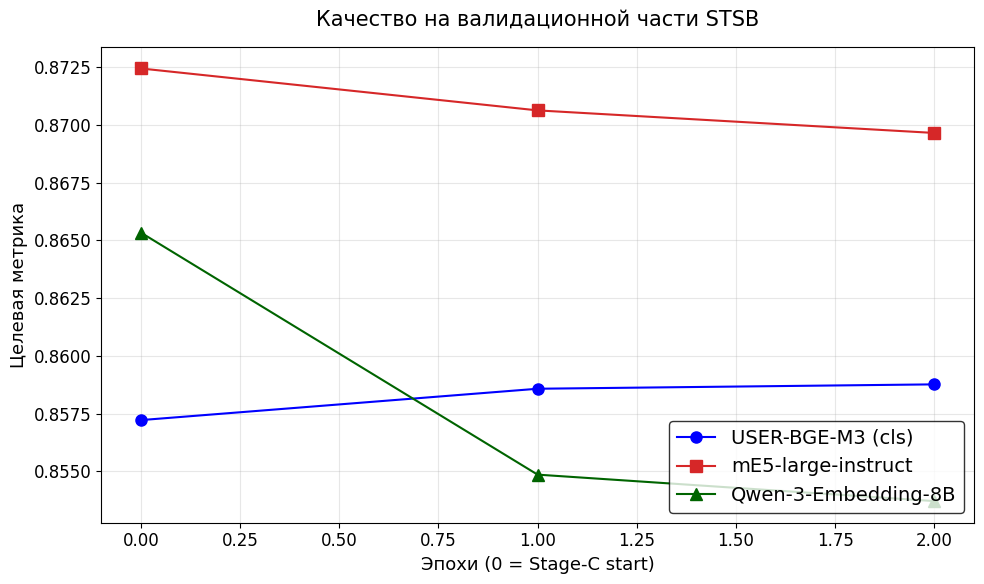

Saved: fig_stsb_test_stageA.png


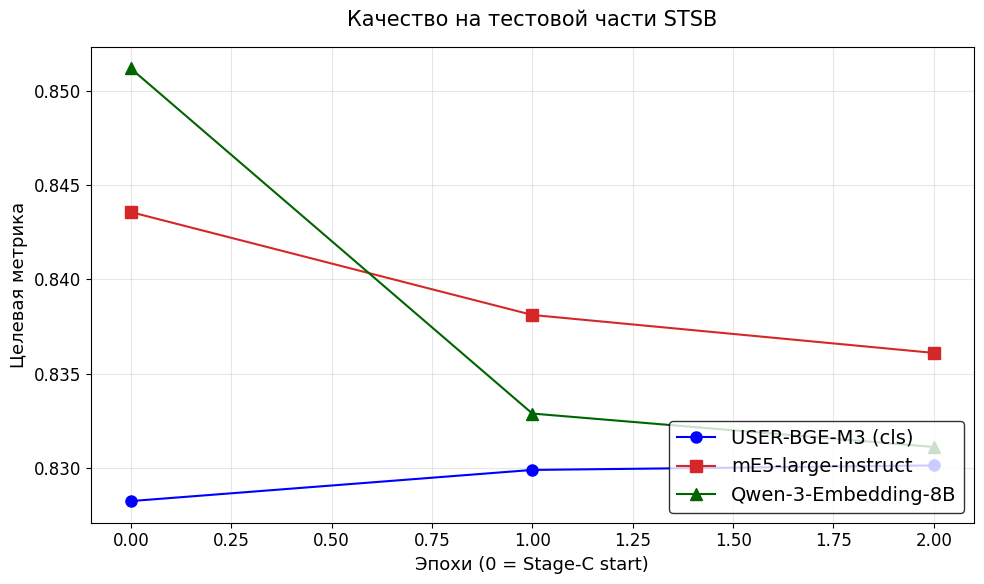

Saved: fig_sts22_test_stageA.png


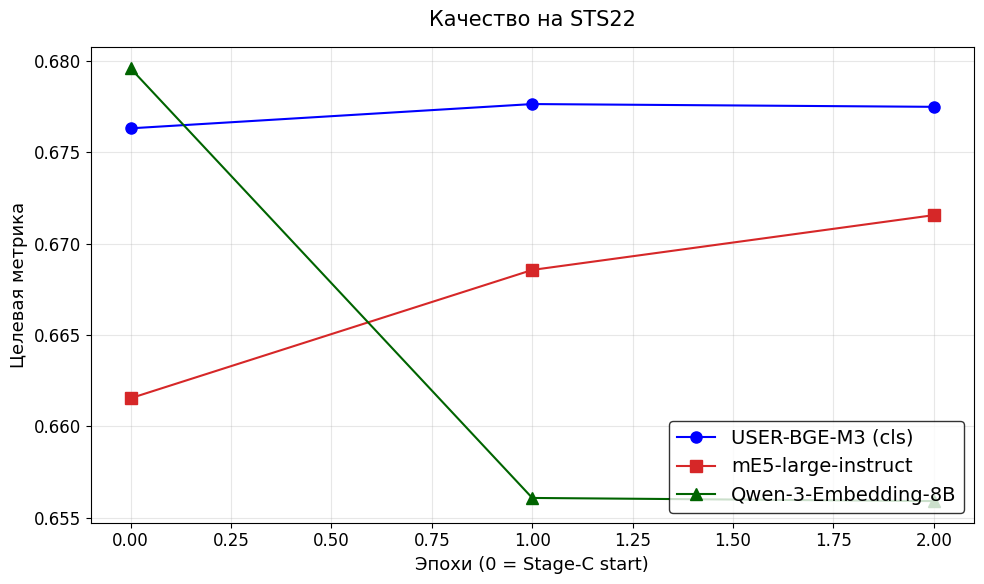

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 14
})

BEST_COLORS = {
    'USER-BGE-M3 (cls)': 'blue',
    'mE5-large-instruct': 'tab:red',
    'Qwen-3-Embedding-8B': 'darkgreen'
}

BEST_MARKERS = {
    'USER-BGE-M3 (cls)': 'o',
    'mE5-large-instruct': 's',
    'Qwen-3-Embedding-8B': '^'
}

def plot_sts_best_styled(histories_dict, metric_key, title, filename, ylabel="Целевая метрика"):
    plt.figure(figsize=(10, 6))

    best_configs = [
        ('USER-bge-m3', 'USER-BGE-M3 (cls)'),
        ('mE5-instruct', 'mE5-large-instruct'),
        ('Qwen3-Emb-8B', 'Qwen-3-Embedding-8B')
    ]

    for model_name, display_label in best_configs:
        if model_name in histories_dict:
            history = histories_dict[model_name]
            if not history: continue

            epochs = [r['epoch'] for r in history]
            values = [r[metric_key] for r in history]

            plt.plot(
                epochs, values,
                label=display_label,
                color=BEST_COLORS.get(display_label, 'black'),
                marker=BEST_MARKERS.get(display_label, 'o'),
                linewidth=1.5,
                markersize=8
            )

    plt.title(title, pad=15)
    plt.xlabel("Эпохи (0 = Stage-C start)")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='-', alpha=0.3)

    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='black')
    plt.tight_layout()

    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.show()

plot_sts_best_styled(HISTORIES, "val_stsb", "Качество на валидационной части STSB", "fig_stsb_val_stageA.png")
plot_sts_best_styled(HISTORIES, "test_stsb", "Качество на тестовой части STSB", "fig_stsb_test_stageA.png")
plot_sts_best_styled(HISTORIES, "test_sts22", "Качество на STS22", "fig_sts22_test_stageA.png")